# HW10-11: Компьютерное зрение в PyTorch

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.morphology import closing, opening, disk, remove_small_objects

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, models, transforms
from torchvision.transforms import functional as TF

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if hasattr(torch.backends, "cudnn"):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [2]:
DATA_DIR = Path("data")
ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"
DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RUNS_COLUMNS = [
    "experiment_id",
    "task",
    "dataset",
    "seed",
    "model_summary",
    "optimizer",
    "lr",
    "epochs_trained",
    "best_val_accuracy",
    "test_accuracy",
    "precision",
    "recall",
    "mean_iou",
    "notes",
]

SVHN_TRAIN_SUBSET = 3000
SVHN_VAL_SUBSET = 1000
SVHN_TEST_SUBSET = 2000
SEG_EVAL_SAMPLES = 120

runs_records = []

In [3]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum = 0.0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)

    return {
        "loss": loss_sum / max(total, 1),
        "accuracy": correct / max(total, 1),
    }


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum = 0.0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        loss_sum += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)

    return {
        "loss": loss_sum / max(total, 1),
        "accuracy": correct / max(total, 1),
    }


def binary_metrics(pred_masks, gt_masks):
    tp = 0
    fp = 0
    fn = 0
    ious = []

    for pred, gt in zip(pred_masks, gt_masks):
        pred_b = pred.astype(bool)
        gt_b = gt.astype(bool)

        inter = np.logical_and(pred_b, gt_b).sum()
        union = np.logical_or(pred_b, gt_b).sum()
        iou = inter / union if union > 0 else 1.0

        ious.append(iou)
        tp += inter
        fp += np.logical_and(pred_b, ~gt_b).sum()
        fn += np.logical_and(~pred_b, gt_b).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 1.0

    return {
        "mean_iou": float(np.mean(ious)) if ious else 0.0,
        "precision": float(precision),
        "recall": float(recall),
    }

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

## Часть A (S10): Классификация SVHN

In [5]:
svhn_mean = [0.4377, 0.4438, 0.4728]
svhn_std = [0.1980, 0.2010, 0.1970]

cnn_base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=svhn_mean, std=svhn_std),
])

cnn_aug_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=svhn_mean, std=svhn_std),
])

aug_preview_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

resnet_weights = models.ResNet18_Weights.DEFAULT
resnet_preprocess = resnet_weights.transforms()

svhn_train_raw = datasets.SVHN(root=DATA_DIR, split="train", download=True, transform=None)
svhn_test_raw = datasets.SVHN(root=DATA_DIR, split="test", download=True, transform=None)

all_train_idx = np.arange(len(svhn_train_raw))
rng = np.random.default_rng(SEED)
rng.shuffle(all_train_idx)

val_size = int(0.2 * len(all_train_idx))
val_idx_full = all_train_idx[:val_size]
train_idx_full = all_train_idx[val_size:]

train_idx = np.sort(rng.choice(train_idx_full, size=min(SVHN_TRAIN_SUBSET, len(train_idx_full)), replace=False))
val_idx = np.sort(rng.choice(val_idx_full, size=min(SVHN_VAL_SUBSET, len(val_idx_full)), replace=False))
test_idx = np.sort(rng.choice(np.arange(len(svhn_test_raw)), size=min(SVHN_TEST_SUBSET, len(svhn_test_raw)), replace=False))


def make_svhn_subset(split, indices, transform):
    ds = datasets.SVHN(root=DATA_DIR, split=split, download=True, transform=transform)
    return Subset(ds, indices.tolist())


svhn_train_base = make_svhn_subset("train", train_idx, cnn_base_transform)
svhn_val_base = make_svhn_subset("train", val_idx, cnn_base_transform)
svhn_test_base = make_svhn_subset("test", test_idx, cnn_base_transform)

svhn_train_aug = make_svhn_subset("train", train_idx, cnn_aug_transform)

svhn_train_resnet = make_svhn_subset("train", train_idx, resnet_preprocess)
svhn_val_resnet = make_svhn_subset("train", val_idx, resnet_preprocess)
svhn_test_resnet = make_svhn_subset("test", test_idx, resnet_preprocess)


def make_loader(dataset, batch_size, shuffle=False):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

loaders = {
    "c1_train": make_loader(svhn_train_base, 128, shuffle=True),
    "c2_train": make_loader(svhn_train_aug, 128, shuffle=True),
    "cnn_val": make_loader(svhn_val_base, 256, shuffle=False),
    "cnn_test": make_loader(svhn_test_base, 256, shuffle=False),
    "resnet_train": make_loader(svhn_train_resnet, 64, shuffle=True),
    "resnet_val": make_loader(svhn_val_resnet, 128, shuffle=False),
    "resnet_test": make_loader(svhn_test_resnet, 128, shuffle=False),
}

x_batch, y_batch = next(iter(loaders["c1_train"]))
print("Part A sanity-check:")
print(f"batch_size={x_batch.shape[0]}, x.shape={tuple(x_batch.shape)}, y.shape={tuple(y_batch.shape)}")
print(f"train/val/test sizes: {len(svhn_train_base)} / {len(svhn_val_base)} / {len(svhn_test_base)}")

Part A sanity-check:
batch_size=128, x.shape=(128, 3, 32, 32), y.shape=(128,)
train/val/test sizes: 3000 / 1000 / 2000


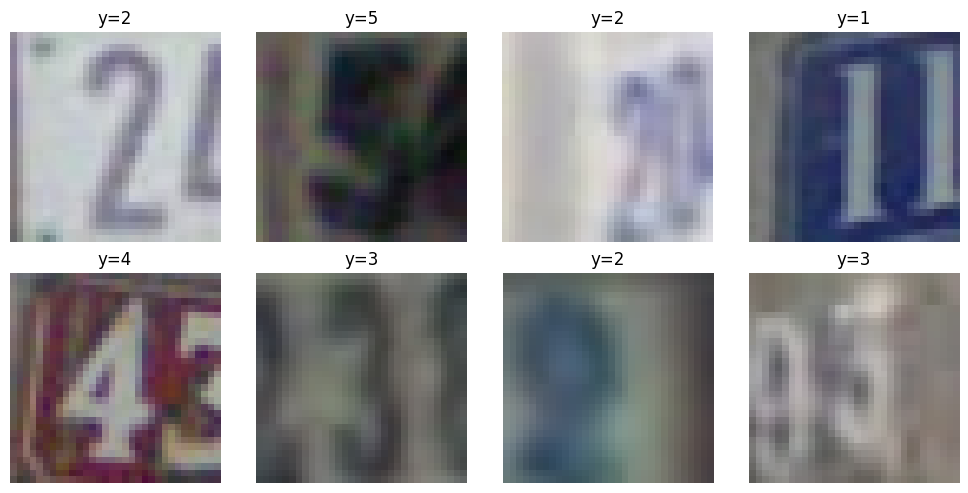

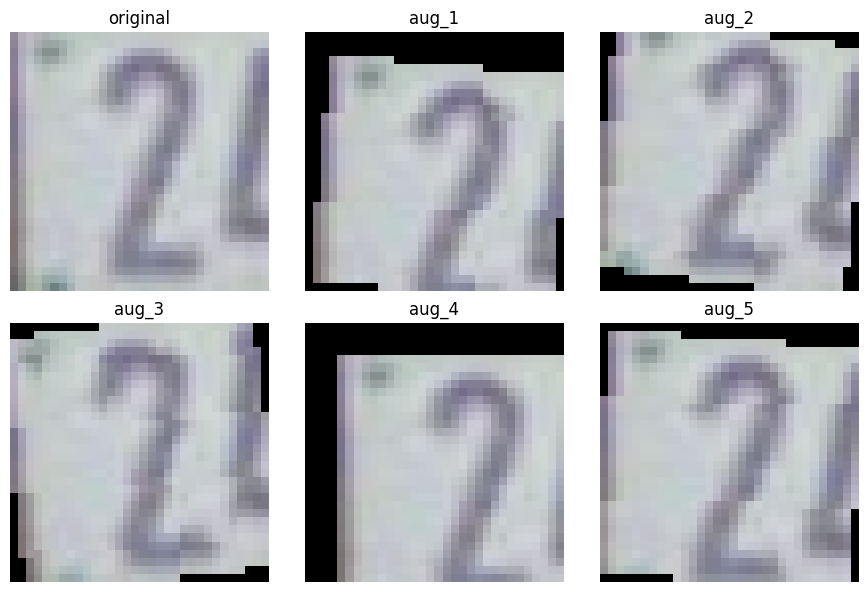

In [6]:
# SVHN samples and augmentation preview
vis_ds = datasets.SVHN(root=DATA_DIR, split="train", download=True, transform=transforms.ToTensor())
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img, label = vis_ds[int(train_idx[i])]
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    ax.set_title(f"y={int(label)}")
    ax.axis("off")
plt.tight_layout()
plt.show()

seed_img_pil, _ = svhn_train_raw[int(train_idx[0])]
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
axes = axes.flat
axes[0].imshow(np.array(seed_img_pil))
axes[0].set_title("original")
axes[0].axis("off")
for i in range(1, 6):
    img_aug = aug_preview_transform(seed_img_pil)
    axes[i].imshow(np.transpose(img_aug.numpy(), (1, 2, 0)).clip(0, 1))
    axes[i].set_title(f"aug_{i}")
    axes[i].axis("off")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "augmentations_preview.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
def build_resnet18_head_only(num_classes=10):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for p in model.parameters():
        p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def build_resnet18_finetune(num_classes=10):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for p in model.parameters():
        p.requires_grad = False
    for p in model.layer4.parameters():
        p.requires_grad = True
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def run_classification_experiment(experiment_id, model, train_loader, val_loader, epochs, lr):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }
    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_metrics = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_acc"].append(train_metrics["accuracy"])
        history["val_acc"].append(val_metrics["accuracy"])

        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"{experiment_id} | epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_metrics['loss']:.4f} train_acc={train_metrics['accuracy']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['accuracy']:.4f}"
        )

    model.load_state_dict(best_state)
    return {
        "model": model,
        "history": history,
        "best_val_acc": float(best_val_acc),
        "epochs": epochs,
        "lr": lr,
    }


Running C1 (simple-cnn-base)


C1 | epoch 01/5 | train_loss=2.2580 train_acc=0.1643 | val_loss=2.2252 val_acc=0.2290


C1 | epoch 02/5 | train_loss=2.1106 train_acc=0.2633 | val_loss=1.8296 val_acc=0.3810


C1 | epoch 03/5 | train_loss=1.4352 train_acc=0.5217 | val_loss=1.1485 val_acc=0.6460


C1 | epoch 04/5 | train_loss=0.9185 train_acc=0.7100 | val_loss=0.9939 val_acc=0.7010


...

C4 | epoch 02/5 | train_loss=0.9242 train_acc=0.7357 | val_loss=1.0887 val_acc=0.6630


C4 | epoch 03/5 | train_loss=0.4918 train_acc=0.8867 | val_loss=0.9860 val_acc=0.6880


C4 | epoch 04/5 | train_loss=0.2496 train_acc=0.9660 | val_loss=0.9450 val_acc=0.6920


C4 | epoch 05/5 | train_loss=0.1195 train_acc=0.9953 | val_loss=0.9252 val_acc=0.7190

Best classification run by val accuracy: C1


Test accuracy (evaluated once, only for best model): 0.7405


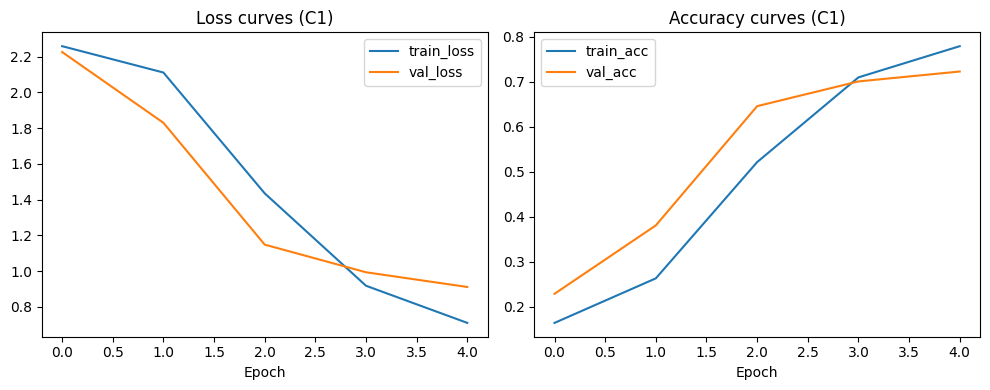

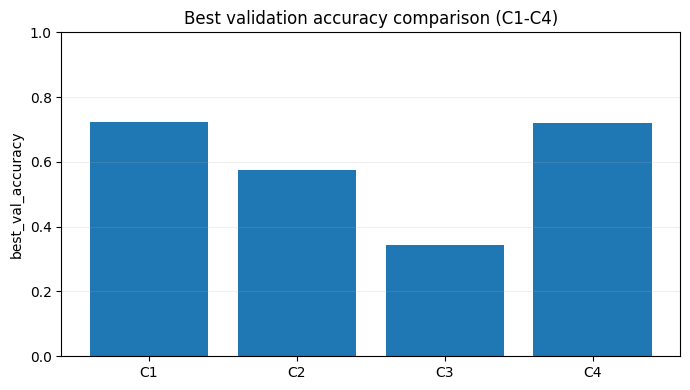

In [8]:
classification_results = {}

classification_plan = [
    {
        "experiment_id": "C1",
        "name": "simple-cnn-base",
        "builder": lambda: SimpleCNN(num_classes=10),
        "train_loader": loaders["c1_train"],
        "val_loader": loaders["cnn_val"],
        "test_loader": loaders["cnn_test"],
        "epochs": 5,
        "lr": 1e-3,
        "model_summary": "SimpleCNN (no aug)",
        "notes": "Same CNN architecture as C2; no augmentations.",
        "transform_desc": "ToTensor + Normalize(SVHN)",
    },
    {
        "experiment_id": "C2",
        "name": "simple-cnn-aug",
        "builder": lambda: SimpleCNN(num_classes=10),
        "train_loader": loaders["c2_train"],
        "val_loader": loaders["cnn_val"],
        "test_loader": loaders["cnn_test"],
        "epochs": 5,
        "lr": 1e-3,
        "model_summary": "SimpleCNN (with aug)",
        "notes": "Same CNN architecture as C1; train augmentations enabled.",
        "transform_desc": "RandomCrop/Flip/ColorJitter/Rotation + Normalize",
    },
    {
        "experiment_id": "C3",
        "name": "resnet18-head-only",
        "builder": lambda: build_resnet18_head_only(num_classes=10),
        "train_loader": loaders["resnet_train"],
        "val_loader": loaders["resnet_val"],
        "test_loader": loaders["resnet_test"],
        "epochs": 5,
        "lr": 1e-3,
        "model_summary": "ResNet18 pretrained, frozen backbone, train fc only",
        "notes": "Transfer learning with frozen backbone.",
        "transform_desc": "ResNet18_Weights.DEFAULT.transforms()",
    },
    {
        "experiment_id": "C4",
        "name": "resnet18-finetune",
        "builder": lambda: build_resnet18_finetune(num_classes=10),
        "train_loader": loaders["resnet_train"],
        "val_loader": loaders["resnet_val"],
        "test_loader": loaders["resnet_test"],
        "epochs": 5,
        "lr": 1e-4,
        "model_summary": "ResNet18 pretrained, layer4+fc trainable",
        "notes": "Partial fine-tuning (layer4 + fc).",
        "transform_desc": "ResNet18_Weights.DEFAULT.transforms()",
    },
]

for cfg in classification_plan:
    print(f"\nRunning {cfg['experiment_id']} ({cfg['name']})")
    result = run_classification_experiment(
        experiment_id=cfg["experiment_id"],
        model=cfg["builder"](),
        train_loader=cfg["train_loader"],
        val_loader=cfg["val_loader"],
        epochs=cfg["epochs"],
        lr=cfg["lr"],
    )
    result["config"] = cfg
    classification_results[cfg["experiment_id"]] = result

    runs_records.append(
        {
            "experiment_id": cfg["experiment_id"],
            "task": "classification",
            "dataset": "SVHN",
            "seed": SEED,
            "model_summary": cfg["model_summary"],
            "optimizer": "Adam",
            "lr": cfg["lr"],
            "epochs_trained": cfg["epochs"],
            "best_val_accuracy": result["best_val_acc"],
            "test_accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "mean_iou": np.nan,
            "notes": cfg["notes"],
        }
    )

best_exp_id = max(classification_results, key=lambda k: classification_results[k]["best_val_acc"])
best_bundle = classification_results[best_exp_id]
best_cfg = best_bundle["config"]

print(f"\nBest classification run by val accuracy: {best_exp_id}")

criterion = nn.CrossEntropyLoss()
test_metrics = evaluate(best_bundle["model"], best_cfg["test_loader"], criterion, device)
print(f"Test accuracy (evaluated once, only for best model): {test_metrics['accuracy']:.4f}")

for row in runs_records:
    if row["experiment_id"] == best_exp_id:
        row["test_accuracy"] = float(test_metrics["accuracy"])
        row["notes"] += " | Selected as best by val accuracy; test evaluated once."

best_model_path = ARTIFACTS_DIR / "best_classifier.pt"
torch.save(best_bundle["model"].state_dict(), best_model_path)

best_config = {
    "dataset": "SVHN",
    "seed": SEED,
    "selected_experiment_id": best_exp_id,
    "architecture": best_cfg["model_summary"],
    "train_transform": best_cfg["transform_desc"],
    "optimizer": "Adam",
    "lr": best_cfg["lr"],
    "epochs": best_cfg["epochs"],
    "split": {
        "train": len(train_idx),
        "val": len(val_idx),
        "test": len(test_idx),
        "train_val_rule": "SVHN train split -> random 80/20, fixed seed, then subset for faster reproducible runs",
    },
}
with open(ARTIFACTS_DIR / "best_classifier_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)

# Curves for best run
hist = best_bundle["history"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(hist["train_loss"], label="train_loss")
axes[0].plot(hist["val_loss"], label="val_loss")
axes[0].set_title(f"Loss curves ({best_exp_id})")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(hist["train_acc"], label="train_acc")
axes[1].plot(hist["val_acc"], label="val_acc")
axes[1].set_title(f"Accuracy curves ({best_exp_id})")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "classification_curves_best.png", dpi=150, bbox_inches="tight")
plt.show()

# C1-C4 comparison
compare_ids = ["C1", "C2", "C3", "C4"]
compare_vals = [classification_results[k]["best_val_acc"] for k in compare_ids]
plt.figure(figsize=(7, 4))
plt.bar(compare_ids, compare_vals)
plt.title("Best validation accuracy comparison (C1-C4)")
plt.ylabel("best_val_accuracy")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "classification_compare.png", dpi=150, bbox_inches="tight")
plt.show()

## Часть B (S11): Сегментация OxfordIIITPet

В части B используется ровно один датасет: `torchvision.datasets.OxfordIIITPet` (segmentation track).

Part B sanity-check:
batch_size=4, x.shape=(4, 3, 256, 256), y.shape=(4, 256, 256)
segmentation eval subset size: 120


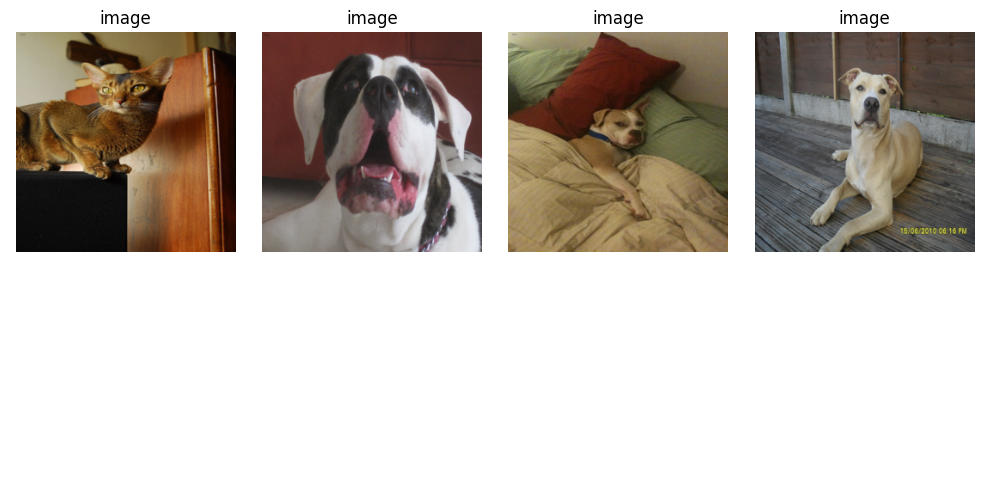

In [9]:
class OxfordPetSegDataset(Dataset):
    def __init__(self, root, split, indices=None, image_size=256):
        self.base = datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=True,
        )
        self.image_size = image_size
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )

        if indices is None:
            self.indices = np.arange(len(self.base))
        else:
            self.indices = np.array(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, trimap = self.base[int(self.indices[idx])]

        image = TF.resize(image, (self.image_size, self.image_size), antialias=True)
        trimap = TF.resize(
            trimap,
            (self.image_size, self.image_size),
            interpolation=transforms.InterpolationMode.NEAREST,
        )

        image_vis = TF.to_tensor(image)
        model_input = self.normalize(image_vis)

        trimap_np = np.array(trimap, dtype=np.uint8)

        # foreground = pet
        gt_fg = (trimap_np == 1).astype(np.uint8)
        
        gt_fg = torch.from_numpy(gt_fg)

        return model_input, gt_fg, image_vis


pet_test_for_len = datasets.OxfordIIITPet(
    root=DATA_DIR,
    split="test",
    target_types="segmentation",
    download=True,
)

rng_seg = np.random.default_rng(SEED)
seg_eval_idx = np.sort(
    rng_seg.choice(
        np.arange(len(pet_test_for_len)),
        size=min(SEG_EVAL_SAMPLES, len(pet_test_for_len)),
        replace=False,
    )
)

pet_eval_ds = OxfordPetSegDataset(root=DATA_DIR, split="test", indices=seg_eval_idx, image_size=256)
pet_loader = DataLoader(
    pet_eval_ds,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

seg_x, seg_y, seg_vis = next(iter(pet_loader))
print("Part B sanity-check:")
print(f"batch_size={seg_x.shape[0]}, x.shape={tuple(seg_x.shape)}, y.shape={tuple(seg_y.shape)}")
print(f"segmentation eval subset size: {len(pet_eval_ds)}")

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    if i >= seg_vis.shape[0]:
        ax.axis("off")
        continue
    ax.imshow(np.transpose(seg_vis[i].numpy(), (1, 2, 0)).clip(0, 1))
    ax.set_title("image")
    ax.axis("off")
plt.tight_layout()
plt.show()

C:\Users\artem\AppData\Local\Temp\ipykernel_89852\2067215983.py:18: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  m = remove_small_objects(m, min_size=300)


Segmentation metrics:
V1: {'mean_iou': 0.738032078482421, 'precision': 0.8078933535695147, 'recall': 0.958058090818651}
V2: {'mean_iou': 0.7629835310163798, 'precision': 0.8501566476232301, 'recall': 0.9398579482033287}


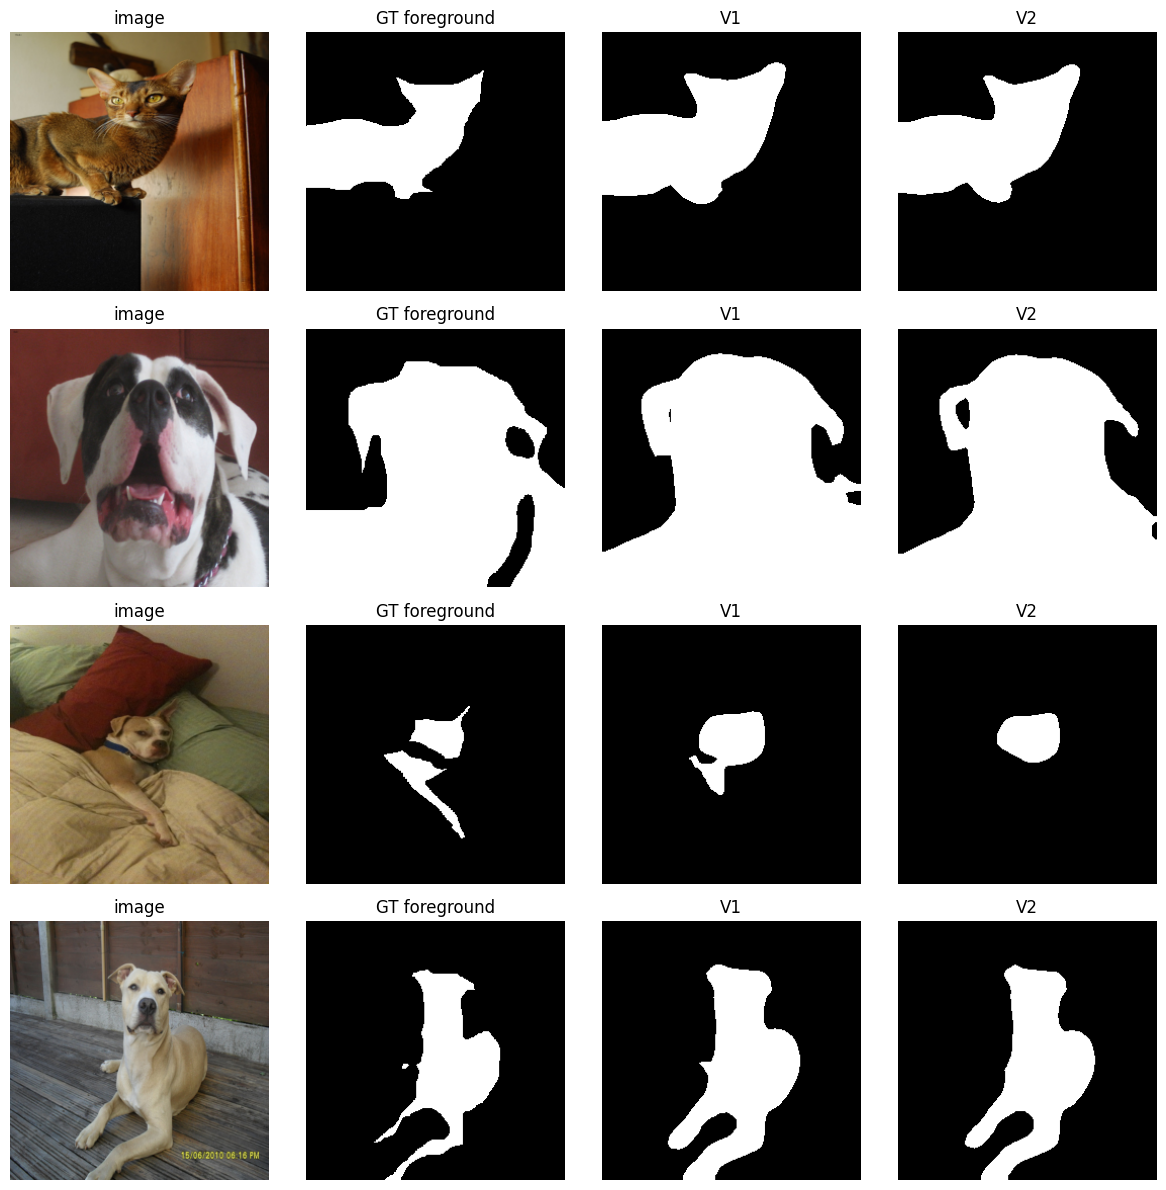

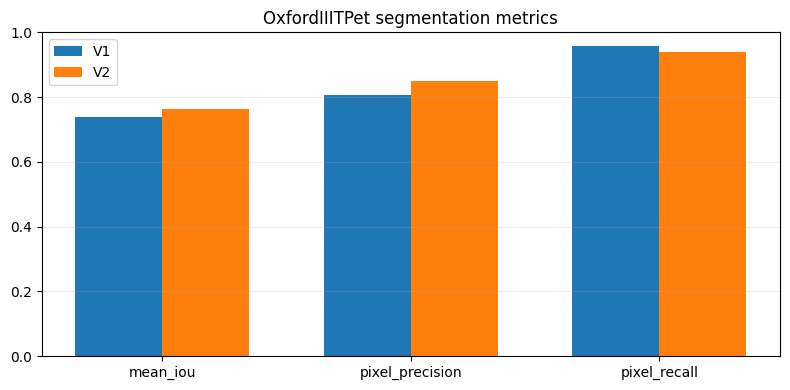

In [10]:
seg_model = models.segmentation.deeplabv3_resnet50(
    weights=models.segmentation.DeepLabV3_ResNet50_Weights.DEFAULT
).to(device)
seg_model.eval()


def postprocess_v1(fg_prob_np):
    """V1: базовая постобработка с порогом 0.5."""
    return (fg_prob_np >= 0.5).astype(np.uint8)


def postprocess_v2(fg_prob_np):
    """V2: порог 0.7 + удаление малых компонент + морфология."""
    pred = (fg_prob_np >= 0.7).astype(np.uint8)
    pred_post = []
    for mask in pred:
        m = mask.astype(bool)
        m = remove_small_objects(m, min_size=300)
        m = opening(m, disk(2))
        m = closing(m, disk(2))
        pred_post.append(m.astype(np.uint8))
    return np.stack(pred_post)


all_gt = []
all_pred_v1 = []
all_pred_v2 = []
examples = []

with torch.no_grad():
    for xb, yb, xvis in pet_loader:
        logits = seg_model(xb.to(device))["out"]
        probs = torch.softmax(logits, dim=1)

        # foreground = pet classes (cat + dog)
        fg_prob = probs[:, 8, :, :] + probs[:, 12, :, :]
        fg_prob_np = fg_prob.cpu().numpy()

        pred_v1 = postprocess_v1(fg_prob_np)
        pred_v2 = postprocess_v2(fg_prob_np)

        gt_np = yb.numpy().astype(np.uint8)

        all_gt.extend(list(gt_np))
        all_pred_v1.extend(list(pred_v1))
        all_pred_v2.extend(list(pred_v2))

        for i in range(xvis.shape[0]):
            if len(examples) < 4:
                examples.append(
                    {
                        "image": np.transpose(xvis[i].numpy(), (1, 2, 0)).clip(0, 1),
                        "gt": gt_np[i],
                        "v1": pred_v1[i],
                        "v2": pred_v2[i],
                    }
                )

metrics_v1 = binary_metrics(all_pred_v1, all_gt)
metrics_v2 = binary_metrics(all_pred_v2, all_gt)

print("Segmentation metrics:")
print("V1:", metrics_v1)
print("V2:", metrics_v2)

fig, axes = plt.subplots(len(examples), 4, figsize=(12, 3 * len(examples)))
if len(examples) == 1:
    axes = np.expand_dims(axes, axis=0)
for r, item in enumerate(examples):
    axes[r, 0].imshow(item["image"])
    axes[r, 0].set_title("image")
    axes[r, 0].axis("off")

    axes[r, 1].imshow(item["gt"], cmap="gray")
    axes[r, 1].set_title("GT foreground")
    axes[r, 1].axis("off")

    axes[r, 2].imshow(item["v1"], cmap="gray")
    axes[r, 2].set_title("V1")
    axes[r, 2].axis("off")

    axes[r, 3].imshow(item["v2"], cmap="gray")
    axes[r, 3].set_title("V2")
    axes[r, 3].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "segmentation_examples.png", dpi=150, bbox_inches="tight")
plt.show()

labels = ["mean_iou", "pixel_precision", "pixel_recall"]
v1_vals = [metrics_v1["mean_iou"], metrics_v1["precision"], metrics_v1["recall"]]
v2_vals = [metrics_v2["mean_iou"], metrics_v2["precision"], metrics_v2["recall"]]

x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(8, 4))
plt.bar(x - width / 2, v1_vals, width, label="V1")
plt.bar(x + width / 2, v2_vals, width, label="V2")
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.title("OxfordIIITPet segmentation metrics")
plt.grid(axis="y", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "segmentation_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

runs_records.append(
    {
        "experiment_id": "V1",
        "task": "segmentation",
        "dataset": "OxfordIIITPet",
        "seed": SEED,
        "model_summary": "DeepLabV3_ResNet50 pretrained",
        "optimizer": np.nan,
        "lr": np.nan,
        "epochs_trained": 0,
        "best_val_accuracy": np.nan,
        "test_accuracy": np.nan,
        "precision": metrics_v1["precision"],
        "recall": metrics_v1["recall"],
        "mean_iou": metrics_v1["mean_iou"],
        "notes": "V1 postprocess: threshold=0.5",
    }
)

runs_records.append(
    {
        "experiment_id": "V2",
        "task": "segmentation",
        "dataset": "OxfordIIITPet",
        "seed": SEED,
        "model_summary": "DeepLabV3_ResNet50 pretrained",
        "optimizer": np.nan,
        "lr": np.nan,
        "epochs_trained": 0,
        "best_val_accuracy": np.nan,
        "test_accuracy": np.nan,
        "precision": metrics_v2["precision"],
        "recall": metrics_v2["recall"],
        "mean_iou": metrics_v2["mean_iou"],
        "notes": "V2 postprocess: threshold=0.7 + remove_small_objects + opening + closing",
    }
)

In [11]:
runs_df = pd.DataFrame(runs_records)
runs_df = runs_df[RUNS_COLUMNS]
runs_df.to_csv(ARTIFACTS_DIR / "runs.csv", index=False)
runs_df

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,SVHN,42,SimpleCNN (no aug),Adam,0.0010,5,0.723,0.7405,NaN,NaN,NaN,Same CNN architecture as C2; no augmentations....
1,C2,classification,SVHN,42,SimpleCNN (with aug),Adam,0.0010,5,0.574,NaN,NaN,NaN,NaN,Same CNN architecture as C1; train augmentatio...
2,C3,classification,SVHN,42,"ResNet18 pretrained, frozen backbone, train fc...",Adam,0.0010,5,0.343,NaN,NaN,NaN,NaN,Transfer learning with frozen backbone.
3,C4,classification,SVHN,42,"ResNet18 pretrained, layer4+fc trainable",Adam,0.0001,5,0.719,NaN,NaN,NaN,NaN,Partial fine-tuning (layer4 + fc).
4,V1,segmentation,OxfordIIITPet,42,DeepLabV3_ResNet50 pretrained,NaN,NaN,0,NaN,NaN,0.807893,0.958058,0.738032,V1 postprocess: threshold=0.5
5,V2,segmentation,OxfordIIITPet,42,DeepLabV3_ResNet50 pretrained,NaN,NaN,0,NaN,NaN,0.850157,0.939858,0.762984,V2 postprocess: threshold=0.7 + remove_small_o...
